In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df= pd.read_csv("C:/Users/Mohan/Documents/candy/data/version_1/Candy_Factories.csv")

In [5]:
df.head()

,Factory,Latitude,Longitude
0,Lot's O' Nuts,32.881893,-111.768036
1,Wicked Choccy's,32.076176,-81.088371
2,Sugar Shack,48.119140,-96.181150
3,Secret Factory,41.446333,-90.565487
4,The Other Factory,35.117500,-89.971107


In [6]:
import plotly.express as px

fig = px.scatter_map(
    df,
    lat="Latitude",
    lon="Longitude",
    text="Factory",          # 👈 show name on map
    zoom=3,
    height=600
)

fig.update_traces(
    textposition="top center"  # position of labels
)

# fig.update_layout(map_style="open-street-map")

fig.show()

![Factory Map](\newplot.png)

In [7]:
from scipy.spatial.distance import cdist

coords = np.radians(df[["Latitude", "Longitude"]].values)

def haversine_vec(u, v):
    lat1, lon1 = u
    lat2, lon2 = v
    R = 6371

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

distance_matrix = pd.DataFrame(
    cdist(coords, coords, metric=haversine_vec),
    index=df["Factory"],
    columns=df["Factory"]
)

distance_matrix

Factory,Lot's O' Nuts,Wicked Choccy's,Sugar Shack,Secret Factory,The Other Factory
Factory,,,,,
Lot's O' Nuts,0.000000,2869.072753,2137.812671,2098.588792,2020.574896
Wicked Choccy's,2869.072753,0.000000,2189.186842,1339.213437,889.070924
Sugar Shack,2137.812671,2189.186842,0.000000,863.723221,1533.821089
Secret Factory,2098.588792,1339.213437,863.723221,0.000000,705.638309
The Other Factory,2020.574896,889.070924,1533.821089,705.638309,0.000000


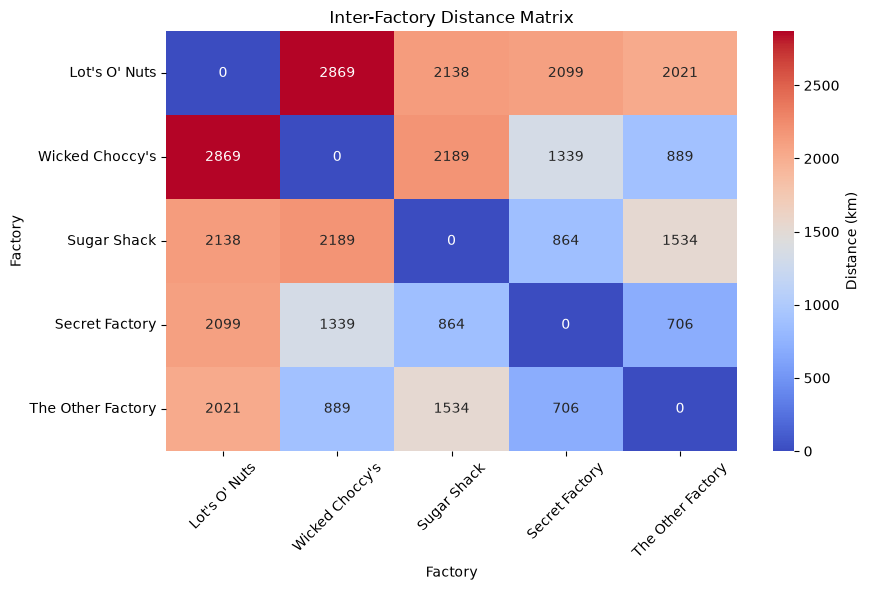

In [8]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    distance_matrix.astype(float),
    cmap="coolwarm",
    annot=True,
    fmt=".0f",
    cbar_kws={'label': 'Distance (km)'}
)

plt.title("Inter-Factory Distance Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

- Secret Factory ↔ The Other Factory — 705.64 km
- Sugar Shack ↔ Secret Factory — 863.72 km
- Wicked Choccy's ↔ The Other Factory — 889.07 km
- Sugar Shack ↔ The Other Factory — 1533.82 km
- Wicked Choccy's ↔ Secret Factory — 1339.21 km
- Lot's O' Nuts ↔ The Other Factory — 2020.57 km
- Lot's O' Nuts ↔ Sugar Shack — 2137.81 km
- Wicked Choccy's ↔ Sugar Shack — 2189.19 km
- Lot's O' Nuts ↔ Secret Factory — 2098.59 km
- Lot's O' Nuts ↔ Wicked Choccy's — 2869.07 km